# MLP Extrapolation Failure: Consolidation Settlement

**Train on [0-2 years]** → **Predict [0-10 years]**

Physics: $S(t) = S_{\text{final}}(1 - e^{-\alpha t})$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from pathlib import Path

torch.manual_seed(42)
np.random.seed(42)

plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11

# Create figures directory
Path('../figures').mkdir(parents=True, exist_ok=True)

## Generate Data

Training: 20 points, t ∈ [0, 2] years
Testing: 200 points, t ∈ [0, 10] years


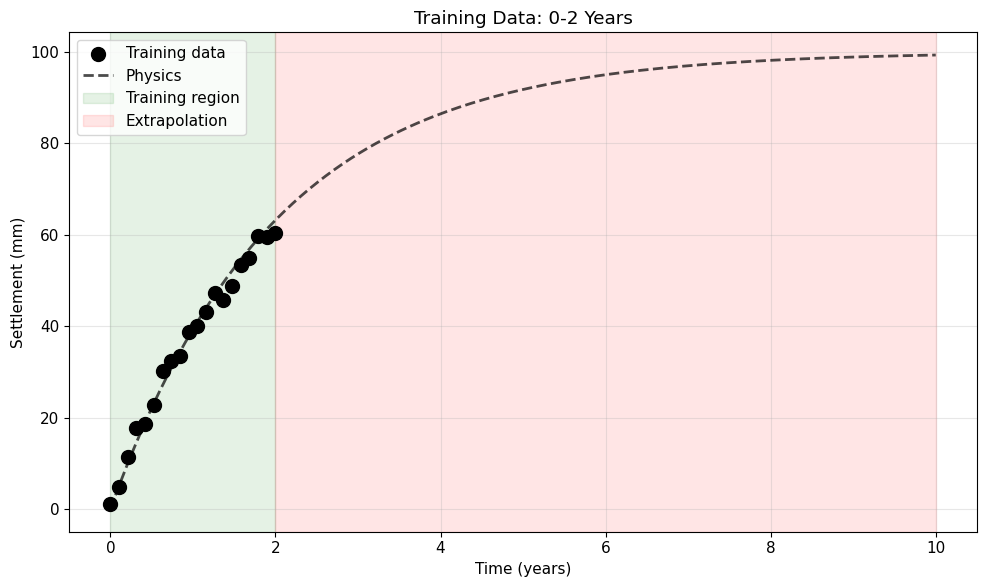

In [2]:
# Physics parameters
S_final = 100.0  # mm
alpha = 0.5      # 1/year

def settlement(t, S_final=100.0, alpha=0.5):
    return S_final * (1.0 - np.exp(-alpha * t))

# Training data: 0-2 years
t_train = np.linspace(0, 2, 20)
S_train = settlement(t_train) + np.random.normal(0, 2, len(t_train))
S_train = np.maximum(S_train, 0)

# Full range: 0-10 years
t_full = np.linspace(0, 10, 200)
S_physics = settlement(t_full)

# Convert to tensors
t_train_t = torch.FloatTensor(t_train.reshape(-1, 1))
S_train_t = torch.FloatTensor(S_train.reshape(-1, 1))
t_full_t = torch.FloatTensor(t_full.reshape(-1, 1))

print(f"Training: {len(t_train)} points, t ∈ [0, {t_train.max():.0f}] years")
print(f"Testing: {len(t_full)} points, t ∈ [0, {t_full.max():.0f}] years")

# Plot training data
plt.figure(figsize=(10, 6))
plt.scatter(t_train, S_train, s=100, color='black', zorder=5, label='Training data')
plt.plot(t_full, S_physics, 'k--', linewidth=2, label='Physics', alpha=0.7)
plt.axvspan(0, 2, alpha=0.1, color='green', label='Training region')
plt.axvspan(2, 10, alpha=0.1, color='red', label='Extrapolation')
plt.xlabel('Time (years)')
plt.ylabel('Settlement (mm)')
plt.title('Training Data: 0-2 Years')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## MLP Architecture

In [ ]:
class MLP(nn.Module):
    def __init__(self, activation='relu'):
        super().__init__()
        self.fc1 = nn.Linear(1, 32)
        self.fc2 = nn.Linear(32, 32)
        self.fc3 = nn.Linear(32, 1)
        
        # Better initialization for ReLU
        if activation == 'relu':
            nn.init.kaiming_normal_(self.fc1.weight, mode='fan_in', nonlinearity='relu')
            nn.init.kaiming_normal_(self.fc2.weight, mode='fan_in', nonlinearity='relu')
        else:
            nn.init.xavier_normal_(self.fc1.weight)
            nn.init.xavier_normal_(self.fc2.weight)
        
        activations = {
            'relu': nn.ReLU(),
            'tanh': nn.Tanh(),
            'sigmoid': nn.Sigmoid(),
        }
        self.act = activations[activation]
        self.name = activation
    
    def forward(self, t):
        x = self.act(self.fc1(t))
        x = self.act(self.fc2(x))
        return self.fc3(x)

def train_model(activation, epochs=3000):
    model = MLP(activation)
    optimizer = optim.Adam(model.parameters(), lr=0.01)
    criterion = nn.MSELoss()
    
    for epoch in range(epochs):
        optimizer.zero_grad()
        loss = criterion(model(t_train_t), S_train_t)
        loss.backward()
        optimizer.step()
    
    model.eval()
    with torch.no_grad():
        pred = model(t_full_t).numpy().flatten()
    
    return model, pred

## Train All Models

In [ ]:
activations = ['relu', 'tanh', 'sigmoid']
models = {}
predictions = {}

for act in activations:
    print(f"Training {act.upper()}...", end=' ')
    model, pred = train_model(act, epochs=3000)
    models[act] = model
    predictions[act] = pred
    print("Done")

print(f"\nAll {len(activations)} models trained")

## Results: Training vs Extrapolation

In [5]:
# Compute errors
train_mask = t_full <= 2.0
extrap_mask = t_full > 2.0

print(f"{'Activation':<10} {'Train RMSE':<12} {'Extrap RMSE':<12} {'Max S':<10} {'Exceeds?'}")
print("-" * 60)

for act in activations:
    pred = predictions[act]
    rmse_train = np.sqrt(np.mean((pred[train_mask] - S_physics[train_mask])**2))
    rmse_extrap = np.sqrt(np.mean((pred[extrap_mask] - S_physics[extrap_mask])**2))
    max_s = pred.max()
    exceeds = "YES" if max_s > S_final + 5 else "NO"
    
    print(f"{act.upper():<10} {rmse_train:>10.2f} mm {rmse_extrap:>10.2f} mm {max_s:>8.1f} mm {exceeds:>7}")

print(f"{'PHYSICS':<10} {'0.00 mm':>12} {'0.00 mm':>12} {S_physics[-1]:>8.1f} mm {'NO':>7}")

Activation Train RMSE   Extrap RMSE  Max S      Exceeds?
------------------------------------------------------------
RELU             2.99 mm     104.34 mm    291.0 mm     YES
TANH             1.59 mm      31.95 mm     60.4 mm      NO
SIGMOID          1.47 mm      31.72 mm     60.7 mm      NO
PHYSICS         0.00 mm      0.00 mm     99.3 mm      NO


## Interpolation: Training Region [0-2 years]

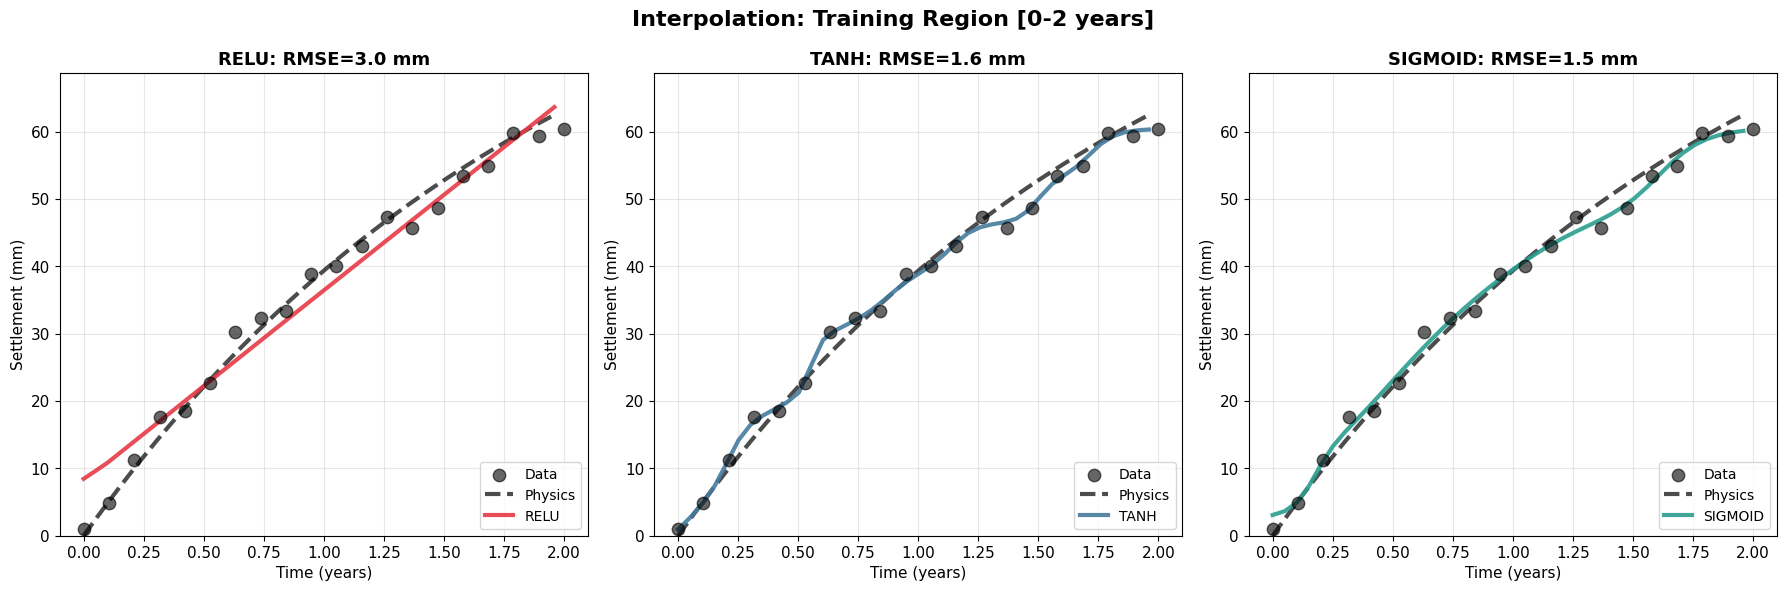

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

colors = {
    'relu': '#E63946',
    'tanh': '#457B9D',
    'sigmoid': '#2A9D8F'
}

for idx, act in enumerate(activations):
    ax = axes[idx]
    
    # Only plot training region
    t_train_region = t_full[train_mask]
    S_train_region = S_physics[train_mask]
    pred_train_region = predictions[act][train_mask]
    
    ax.scatter(t_train, S_train, s=80, color='black', zorder=5, alpha=0.6, label='Data')
    ax.plot(t_train_region, S_train_region, 'k--', linewidth=3, label='Physics', alpha=0.7)
    ax.plot(t_train_region, pred_train_region, color=colors[act], linewidth=3, 
            label=f'{act.upper()}', alpha=0.9)
    
    rmse_train = np.sqrt(np.mean((pred_train_region - S_train_region)**2))
    
    ax.set_title(f'{act.upper()}: RMSE={rmse_train:.1f} mm', 
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Time (years)', fontsize=11)
    ax.set_ylabel('Settlement (mm)', fontsize=11)
    ax.legend(loc='lower right', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-0.1, 2.1)
    ax.set_ylim(0, S_train_region.max()*1.1)

plt.suptitle('Interpolation: Training Region [0-2 years]', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/interpolation.png', dpi=300, bbox_inches='tight')
plt.show()

## Extrapolation: Full Range [0-10 years]

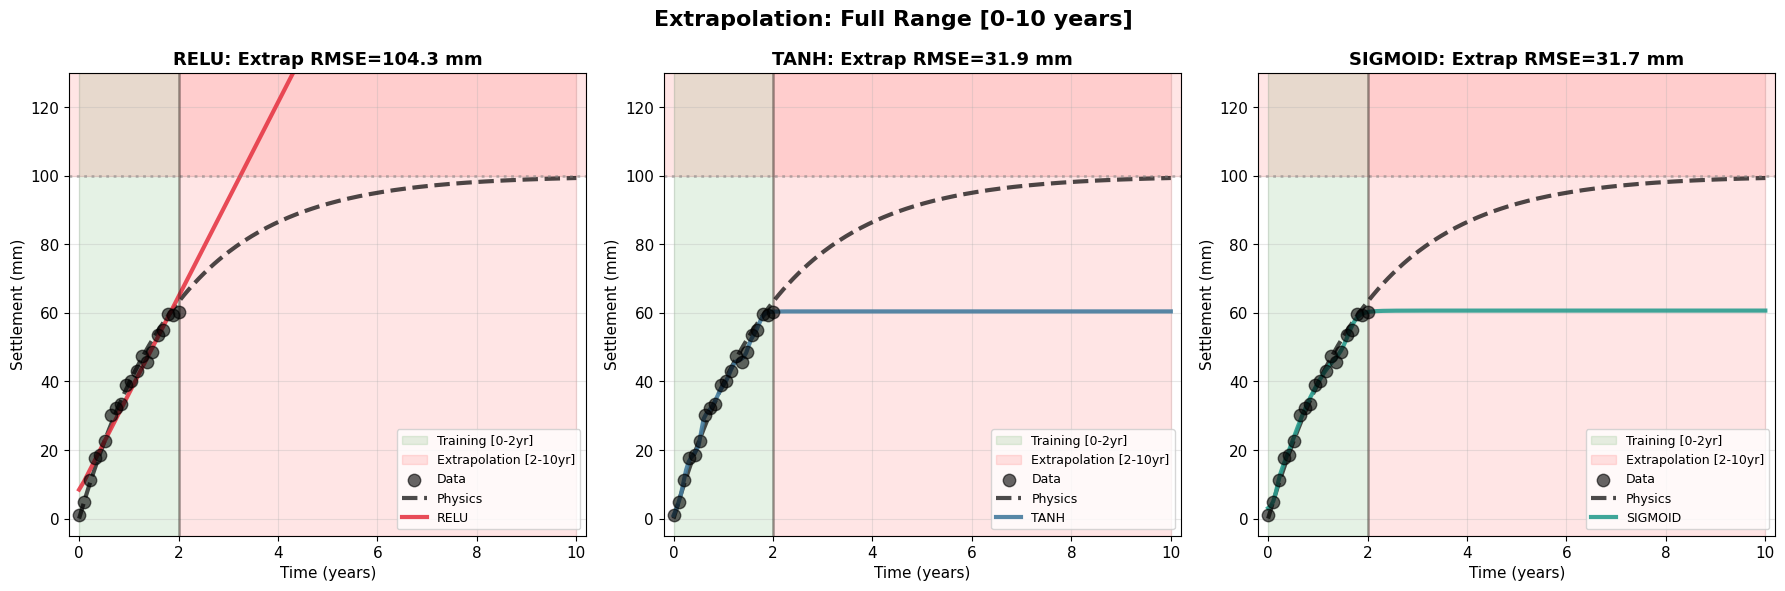


20-Year Predictions:
Activation S(20yr)      Error
-----------------------------------
RELU            573.5 mm    473.5 mm
TANH             60.4 mm     39.6 mm
SIGMOID          60.7 mm     39.3 mm
PHYSICS         100.0 mm   0.0 mm


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, act in enumerate(activations):
    ax = axes[idx]
    
    # Full range [0-10 years]
    ax.axvspan(0, 2, alpha=0.1, color='green', label='Training [0-2yr]')
    ax.axvspan(2, 10, alpha=0.1, color='red', label='Extrapolation [2-10yr]')
    ax.axhspan(S_final, S_final*1.3, alpha=0.1, color='red')
    
    ax.scatter(t_train, S_train, s=80, color='black', zorder=5, alpha=0.6, label='Data')
    ax.plot(t_full, S_physics, 'k--', linewidth=3, label='Physics', alpha=0.7)
    ax.plot(t_full, predictions[act], color=colors[act], linewidth=3, 
            label=f'{act.upper()}', alpha=0.9)
    
    ax.axhline(S_final, color='gray', linestyle=':', linewidth=2, alpha=0.5)
    ax.axvline(2.0, color='black', linestyle='-', linewidth=2, alpha=0.3)
    
    pred = predictions[act]
    rmse_extrap = np.sqrt(np.mean((pred[extrap_mask] - S_physics[extrap_mask])**2))
    
    ax.set_title(f'{act.upper()}: Extrap RMSE={rmse_extrap:.1f} mm', 
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Time (years)', fontsize=11)
    ax.set_ylabel('Settlement (mm)', fontsize=11)
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-0.2, 10.2)
    ax.set_ylim(-5, S_final*1.3)

plt.suptitle('Extrapolation: Full Range [0-10 years]', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/extrapolation.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n20-Year Predictions:")
print(f"{'Activation':<10} {'S(20yr)':<12} {'Error'}")
print("-" * 35)

t_ext = np.linspace(0, 20, 400)
S_ext_physics = settlement(t_ext)
t_ext_t = torch.FloatTensor(t_ext.reshape(-1, 1))

for act in activations:
    with torch.no_grad():
        pred_20 = models[act](torch.FloatTensor([[20.0]])).item()
    error = abs(pred_20 - S_ext_physics[-1])
    print(f"{act.upper():<10} {pred_20:>10.1f} mm {error:>8.1f} mm")
print(f"{'PHYSICS':<10} {S_ext_physics[-1]:>10.1f} mm {'0.0 mm':>8}")

## Summary

**Key Findings:**
1. All models fit training data well (RMSE < 5mm)
2. All models fail in extrapolation
3. ReLU worst: linear extrapolation → unbounded growth
4. Bounded activations (Tanh, Sigmoid) better but still wrong

**Lesson:** Training accuracy ≠ Extrapolation reliability